# CMPE256 Group 12 - Phase 1
## Data Exploration and Data Preprocessing

### Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast

# Robust helper function to load datasets line by line
def load_json_data(filepath, max_records=None):
    records = []
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for i, line in enumerate(f):
            if max_records is not None and i >= max_records:
                break
            line = line.strip()
            if not line:
                continue
            try:
                # Try strict JSON first
                records.append(json.loads(line))
            except json.JSONDecodeError:
                try:
                    # Fallback to python dictionary evaluation (common in some web scrape dumps)
                    records.append(ast.literal_eval(line))
                except (ValueError, SyntaxError):
                    pass
    return pd.DataFrame(records)

# set max_records=None for the whole file
print("Loading RateBeer data...")
df_rb = load_json_data('/content/ratebeer.json', max_records=None)

print("\nLoading BeerAdvocate data...")
df_ba = load_json_data('/content/beeradvocate.json', max_records=None)

print("\nRateBeer Head:")
display(df_rb.head(3))

print("\nBeerAdvocate Head:")
display(df_ba.head(3))

Loading RateBeer data...

Loading BeerAdvocate data...

RateBeer Head:


,beer/name,beer/beerId,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time,review/profileName,review/text
0,John Harvards Simcoe IPA,63836,8481,5.4,India Pale Ale &#40;IPA&#41;,4/5,6/10,3/5,6/10,13/20,1157587200,hopdog,"On tap at the Springfield, PA location. Poured..."
1,John Harvards Simcoe IPA,63836,8481,5.4,India Pale Ale &#40;IPA&#41;,4/5,6/10,4/5,7/10,13/20,1157241600,TomDecapolis,On tap at the John Harvards in Springfield PA....
2,John Harvards Cristal Pilsner,71716,8481,5,Bohemian Pilsener,4/5,5/10,3/5,6/10,14/20,958694400,PhillyBeer2112,"UPDATED: FEB 19, 2003 Springfield, PA. I've ne..."



BeerAdvocate Head:


,beer/name,beer/beerId,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time,review/profileName,review/text
0,Sausa Weizen,47986,10325,5.00,Hefeweizen,2.5,2,1.5,1.5,1.5,1234817823,stcules,A lot of foam. But a lot.\tIn the smell some b...
1,Red Moon,48213,10325,6.20,English Strong Ale,3,2.5,3,3,3,1235915097,stcules,"Dark red color, light beige foam, average.\tIn..."
2,Black Horse Black Beer,48215,10325,6.50,Foreign / Export Stout,3,2.5,3,3,3,1235916604,stcules,"Almost totally black. Beige foam, quite compac..."


### Dataset Statistics

In [2]:
if 'df_rb' in locals() and 'df_ba' in locals():
    print("=== RateBeer Dataset Info ===")
    print(f"Shape: {df_rb.shape}")
    print("\nMissing Values:")
    print(df_rb.isnull().sum())

    print("\n\n=== BeerAdvocate Dataset Info ===")
    print(f"Shape: {df_ba.shape}")
    print("\nMissing Values:")
    print(df_ba.isnull().sum())
else:
    print("DataFrames are not defined. Please ensure the data loading cell runs successfully first.")

=== RateBeer Dataset Info ===
Shape: (2924164, 13)

Missing Values:
beer/name             1
beer/beerId           1
beer/brewerId         1
beer/ABV              1
beer/style            1
review/appearance     1
review/aroma          1
review/palate         1
review/taste          1
review/overall        1
review/time           1
review/profileName    1
review/text           1
dtype: int64


=== BeerAdvocate Dataset Info ===
Shape: (1586615, 13)

Missing Values:
beer/name             1
beer/beerId           1
beer/brewerId         1
beer/ABV              1
beer/style            1
review/appearance     1
review/aroma          1
review/palate         1
review/taste          1
review/overall        1
review/time           1
review/profileName    1
review/text           1
dtype: int64


### Data Preprocessing (Rating Normalization)

In [3]:
def parse_fraction(val):
    if pd.isna(val):
        return val
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        try:
            if '/' in val:
                num, den = val.split('/')
                # Normalize to a 5-point scale based on the denominator
                return (float(num) / float(den)) * 5.0
            else:
                return float(val)
        except (ValueError, ZeroDivisionError):
            return None
    return None

# Apply parsing to RateBeer
# create generic user_id, item_id, rating columns
print("Processing RateBeer dataset...")
df_rb['rating'] = df_rb['review/overall'].apply(parse_fraction)
df_rb['user_id'] = df_rb['review/profileName']
df_rb['item_id'] = df_rb['beer/beerId']

# Apply parsing to BeerAdvocate
# create generic user_id, item_id, rating columns
print("Processing BeerAdvocate dataset...")
df_ba['rating'] = df_ba['review/overall'].apply(parse_fraction)
df_ba['user_id'] = df_ba['review/profileName']
df_ba['item_id'] = df_ba['beer/beerId']

# Drop rows with invalid ratings
df_rb.dropna(subset=['rating', 'user_id', 'item_id'], inplace=True)
df_ba.dropna(subset=['rating', 'user_id', 'item_id'], inplace=True)

print("RateBeer Cleaned Sample:")
print(f"Shape: {df_rb.shape}")
display(df_rb[['user_id', 'item_id', 'rating', 'review/overall']].head())

print("\nBeerAdvocate Cleaned Sample:")
print(f"Shape: {df_ba.shape}")
display(df_ba[['user_id', 'item_id', 'rating', 'review/overall']].head())

Processing RateBeer dataset...
Processing BeerAdvocate dataset...
RateBeer Cleaned Sample:
Shape: (2924163, 16)


,user_id,item_id,rating,review/overall
0,hopdog,63836,3.25,13/20
1,TomDecapolis,63836,3.25,13/20
2,PhillyBeer2112,71716,3.50,14/20
3,TomDecapolis,64125,2.00,8/20
4,hopdog,64125,2.00,8/20



BeerAdvocate Cleaned Sample:
Shape: (1586614, 16)


,user_id,item_id,rating,review/overall
0,stcules,47986,1.5,1.5
1,stcules,48213,3.0,3
2,stcules,48215,3.0,3
3,stcules,47969,3.0,3
4,johnmichaelsen,64883,4.0,4


### EDA: Distributions and Sparsity

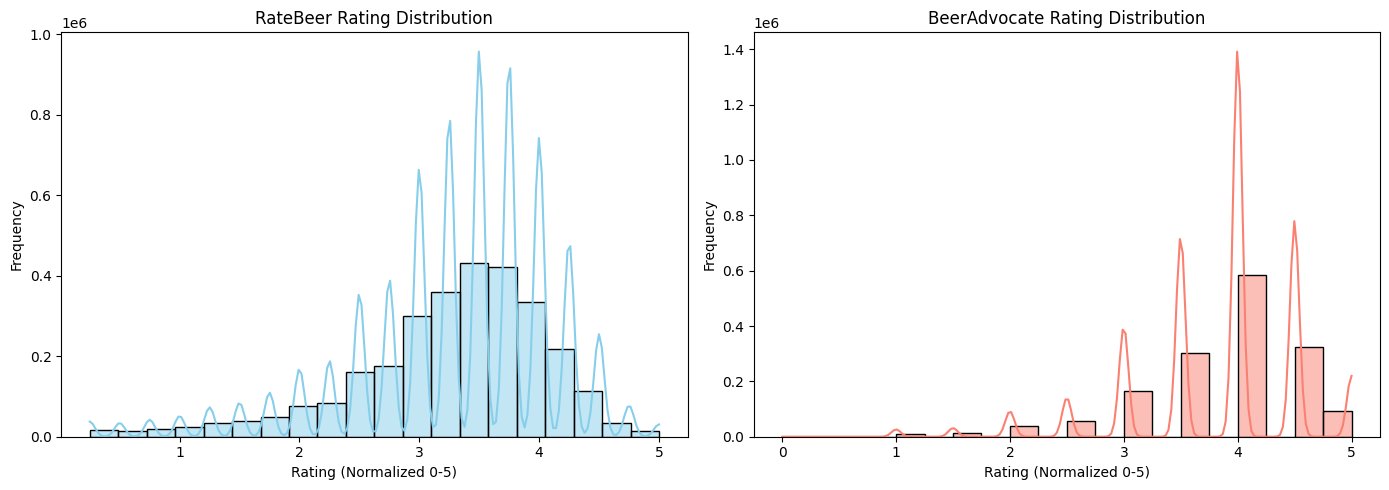

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot RateBeer Rating Distribution
sns.histplot(df_rb['rating'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('RateBeer Rating Distribution')
axes[0].set_xlabel('Rating (Normalized 0-5)')
axes[0].set_ylabel('Frequency')

# Plot BeerAdvocate Rating Distribution
sns.histplot(df_ba['rating'], bins=20, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('BeerAdvocate Rating Distribution')
axes[1].set_xlabel('Rating (Normalized 0-5)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

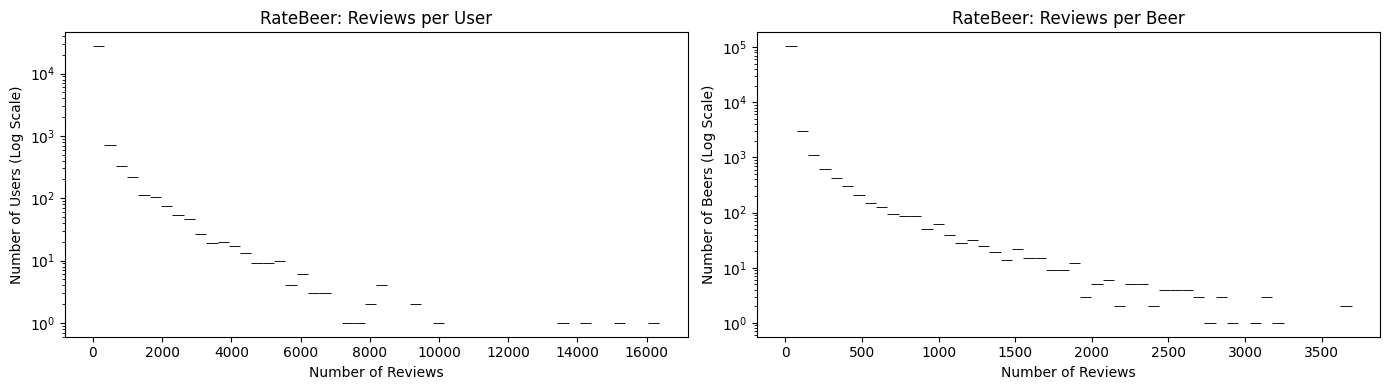

--- RateBeer Sparsity Stats ---
Total Ratings: 2924163
Unique Users: 29265
Unique Beers: 110369
Matrix Density: 0.000905



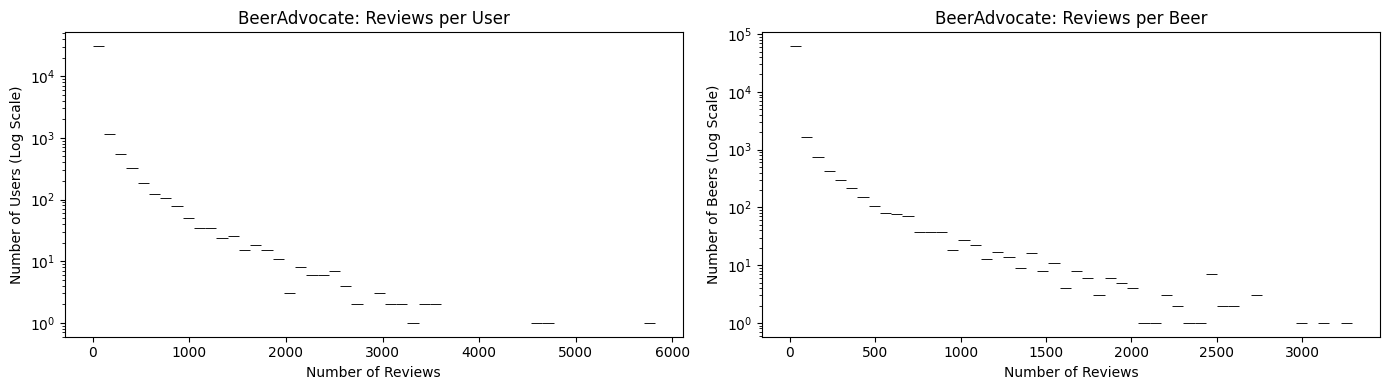

--- BeerAdvocate Sparsity Stats ---
Total Ratings: 1586614
Unique Users: 33388
Unique Beers: 66055
Matrix Density: 0.000719



In [5]:
def plot_interaction_counts(df, dataset_name):
    user_counts = df['user_id'].value_counts()
    item_counts = df['item_id'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Reviews per user (Log Scale)
    sns.histplot(user_counts, bins=50, log_scale=(False, True), ax=axes[0], color='purple')
    axes[0].set_title(f'{dataset_name}: Reviews per User')
    axes[0].set_xlabel('Number of Reviews')
    axes[0].set_ylabel('Number of Users (Log Scale)')

    # Reviews per item (Log Scale)
    sns.histplot(item_counts, bins=50, log_scale=(False, True), ax=axes[1], color='orange')
    axes[1].set_title(f'{dataset_name}: Reviews per Beer')
    axes[1].set_xlabel('Number of Reviews')
    axes[1].set_ylabel('Number of Beers (Log Scale)')

    plt.tight_layout()
    plt.show()

    print(f"--- {dataset_name} Sparsity Stats ---")
    print(f"Total Ratings: {len(df)}")
    print(f"Unique Users: {len(user_counts)}")
    print(f"Unique Beers: {len(item_counts)}")
    density = len(df) / (len(user_counts) * len(item_counts)) if len(user_counts) * len(item_counts) > 0 else 0
    print(f"Matrix Density: {density:.6f}\n")

plot_interaction_counts(df_rb, 'RateBeer')
plot_interaction_counts(df_ba, 'BeerAdvocate')

### Additional Statistics and Cold-Start Analysis

In [6]:
def detailed_stats(df, name):
    users = df['user_id'].nunique()
    items = df['item_id'].nunique()
    interactions = len(df)
    density = interactions / (users * items) if users * items > 0 else 0
    avg_per_user = interactions / users if users > 0 else 0
    avg_per_item = interactions / items if items > 0 else 0

    print(f"=== {name} Detailed Statistics ===")
    print(f"Total Interactions: {interactions}")
    print(f"Unique Users: {users}")
    print(f"Unique Items: {items}")
    print(f"Matrix Density: {density:.6f}")
    print(f"Avg Interactions per User: {avg_per_user:.2f}")
    print(f"Avg Interactions per Item: {avg_per_item:.2f}\n")

def cold_start_analysis(df, name, threshold=5):
    user_counts = df['user_id'].value_counts()
    item_counts = df['item_id'].value_counts()
    cold_users = (user_counts < threshold).sum()
    cold_items = (item_counts < threshold).sum()

    print(f"=== {name} Cold-Start (Threshold < {threshold} interactions) ===")
    print(f"Users with < {threshold} reviews: {cold_users} ({cold_users/len(user_counts)*100:.2f}% of all users)")
    print(f"Items with < {threshold} reviews: {cold_items} ({cold_items/len(item_counts)*100:.2f}% of all items)\n")

detailed_stats(df_rb, "RateBeer")
cold_start_analysis(df_rb, "RateBeer")

detailed_stats(df_ba, "BeerAdvocate")
cold_start_analysis(df_ba, "BeerAdvocate")

=== RateBeer Detailed Statistics ===
Total Interactions: 2924163
Unique Users: 29265
Unique Items: 110369
Matrix Density: 0.000905
Avg Interactions per User: 99.92
Avg Interactions per Item: 26.49

=== RateBeer Cold-Start (Threshold < 5 interactions) ===
Users with < 5 reviews: 16499 (56.38% of all users)
Items with < 5 reviews: 56494 (51.19% of all items)

=== BeerAdvocate Detailed Statistics ===
Total Interactions: 1586614
Unique Users: 33388
Unique Items: 66055
Matrix Density: 0.000719
Avg Interactions per User: 47.52
Avg Interactions per Item: 24.02

=== BeerAdvocate Cold-Start (Threshold < 5 interactions) ===
Users with < 5 reviews: 18576 (55.64% of all users)
Items with < 5 reviews: 43677 (66.12% of all items)



### Data Quality Issues and Metadata Overview

In [7]:
print("=== Data Quality: Duplicate Interactions ===")
rb_dups = df_rb.duplicated(subset=['user_id', 'item_id']).sum()
ba_dups = df_ba.duplicated(subset=['user_id', 'item_id']).sum()
print(f"RateBeer duplicated user-item pairs: {rb_dups} ({rb_dups/len(df_rb)*100:.2f}%)")
print(f"BeerAdvocate duplicated user-item pairs: {ba_dups} ({ba_dups/len(df_ba)*100:.2f}%)")

print("\n=== Available Metadata Overview ===")
metadata_cols = [c for c in df_rb.columns if c not in ['user_id', 'review/profileName', 'item_id',
                                                       'beer/beerId', 'rating', 'review/overall']]
print("Features available beyond IDs and overall rating:")
for col in metadata_cols:
    print(f"- {col} (Type: {df_rb[col].dtype})")

# Example of metadata values
print("\nExample Metadata (RateBeer):")
display(df_rb[metadata_cols].head(2))

=== Data Quality: Duplicate Interactions ===
RateBeer duplicated user-item pairs: 68931 (2.36%)
BeerAdvocate duplicated user-item pairs: 14806 (0.93%)

=== Available Metadata Overview ===
Features available beyond IDs and overall rating:
- beer/name (Type: object)
- beer/brewerId (Type: object)
- beer/ABV (Type: object)
- beer/style (Type: object)
- review/appearance (Type: object)
- review/aroma (Type: object)
- review/palate (Type: object)
- review/taste (Type: object)
- review/time (Type: object)
- review/text (Type: object)

Example Metadata (RateBeer):


,beer/name,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/time,review/text
0,John Harvards Simcoe IPA,8481,5.4,India Pale Ale &#40;IPA&#41;,4/5,6/10,3/5,6/10,1157587200,"On tap at the Springfield, PA location. Poured..."
1,John Harvards Simcoe IPA,8481,5.4,India Pale Ale &#40;IPA&#41;,4/5,6/10,4/5,7/10,1157241600,On tap at the John Harvards in Springfield PA....


### Unified Dataset Merging

In [8]:
import pandas as pd

# Create copies to avoid altering original clean DataFrames
df_rb_merge = df_rb.copy()
df_ba_merge = df_ba.copy()

# Filter BeerAdvocate data to start from April 2000 to match RateBeer's timeline
# April 1, 2000 as a UNIX timestamp is approximately 954547200
cutoff_timestamp = pd.Timestamp('2000-04-01').timestamp()
ba_times = pd.to_numeric(df_ba_merge['review/time'], errors='coerce')

records_before = len(df_ba_merge)
df_ba_merge = df_ba_merge[ba_times >= cutoff_timestamp].copy()
records_after = len(df_ba_merge)
print(f"Filtered BeerAdvocate reviews before April 2000. Dropped {records_before - records_after} older records.")

# Prefix IDs to prevent collisions across platforms
df_rb_merge['user_id'] = 'rb_' + df_rb_merge['user_id'].astype(str)
df_rb_merge['item_id'] = 'rb_' + df_rb_merge['item_id'].astype(str)
df_rb_merge['source'] = 'RateBeer'

df_ba_merge['user_id'] = 'ba_' + df_ba_merge['user_id'].astype(str)
df_ba_merge['item_id'] = 'ba_' + df_ba_merge['item_id'].astype(str)
df_ba_merge['source'] = 'BeerAdvocate'

# Concatenate into a unified dataset
df_unified = pd.concat([df_rb_merge, df_ba_merge], ignore_index=True)

print("\nUnified Dataset Head:")
display(df_unified[['user_id', 'item_id', 'rating', 'source']].head())
print(f"\nTotal records in unified dataset: {len(df_unified)}")

Filtered BeerAdvocate reviews before April 2000. Dropped 221 older records.

Unified Dataset Head:


,user_id,item_id,rating,source
0,rb_hopdog,rb_63836,3.25,RateBeer
1,rb_TomDecapolis,rb_63836,3.25,RateBeer
2,rb_PhillyBeer2112,rb_71716,3.50,RateBeer
3,rb_TomDecapolis,rb_64125,2.00,RateBeer
4,rb_hopdog,rb_64125,2.00,RateBeer



Total records in unified dataset: 4510556


In [9]:
# Check for overall duplicates in the combined dataset
uni_dups = df_unified.duplicated(subset=['user_id', 'item_id']).sum()
print(f"Unified duplicated user-item pairs: {uni_dups} ({uni_dups/len(df_unified)*100:.2f}%)")

Unified duplicated user-item pairs: 83732 (1.86%)


### Unified Dataset Deduplication and Visualizations

In [10]:
print(f"Records before dropping duplicates: {len(df_unified)}")

# Drop duplicates based on user_id and item_id, keeping the first occurrence
df_unified.drop_duplicates(subset=['user_id', 'item_id'], keep='first', inplace=True)

print(f"Records after dropping duplicates: {len(df_unified)}")

Records before dropping duplicates: 4510556
Records after dropping duplicates: 4426824


In [11]:
# We can reuse the previously defined functions to get statistics on the unified dataset
print("Calculating statistics for the Unified Dataset...\n")

detailed_stats(df_unified, "Unified Dataset")
cold_start_analysis(df_unified, "Unified Dataset", threshold=5)

Calculating statistics for the Unified Dataset...

=== Unified Dataset Detailed Statistics ===
Total Interactions: 4426824
Unique Users: 62653
Unique Items: 176343
Matrix Density: 0.000401
Avg Interactions per User: 70.66
Avg Interactions per Item: 25.10

=== Unified Dataset Cold-Start (Threshold < 5 interactions) ===
Users with < 5 reviews: 35246 (56.26% of all users)
Items with < 5 reviews: 100396 (56.93% of all items)



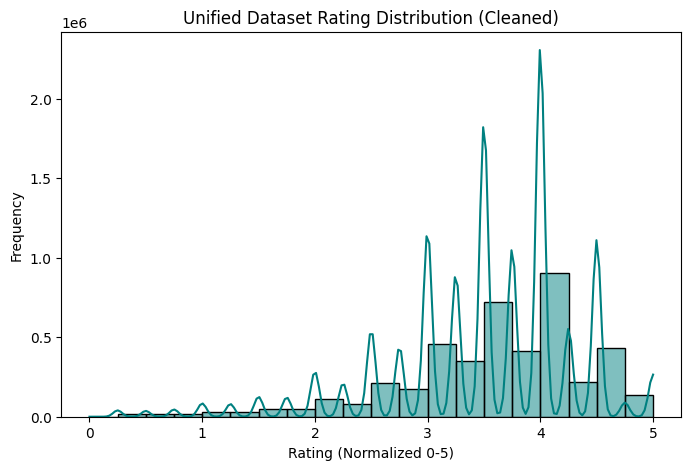

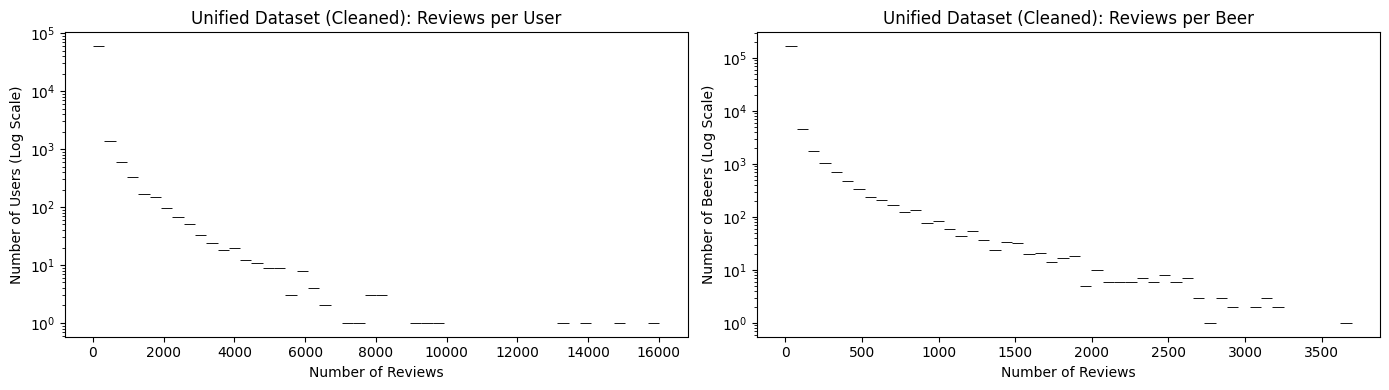

--- Unified Dataset (Cleaned) Sparsity Stats ---
Total Ratings: 4426824
Unique Users: 62653
Unique Beers: 176343
Matrix Density: 0.000401



In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Unified Rating Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_unified['rating'], bins=20, kde=True, color='teal')
plt.title('Unified Dataset Rating Distribution (Cleaned)')
plt.xlabel('Rating (Normalized 0-5)')
plt.ylabel('Frequency')
plt.show()

# Interaction Counts using the previously defined function
plot_interaction_counts(df_unified, 'Unified Dataset (Cleaned)')

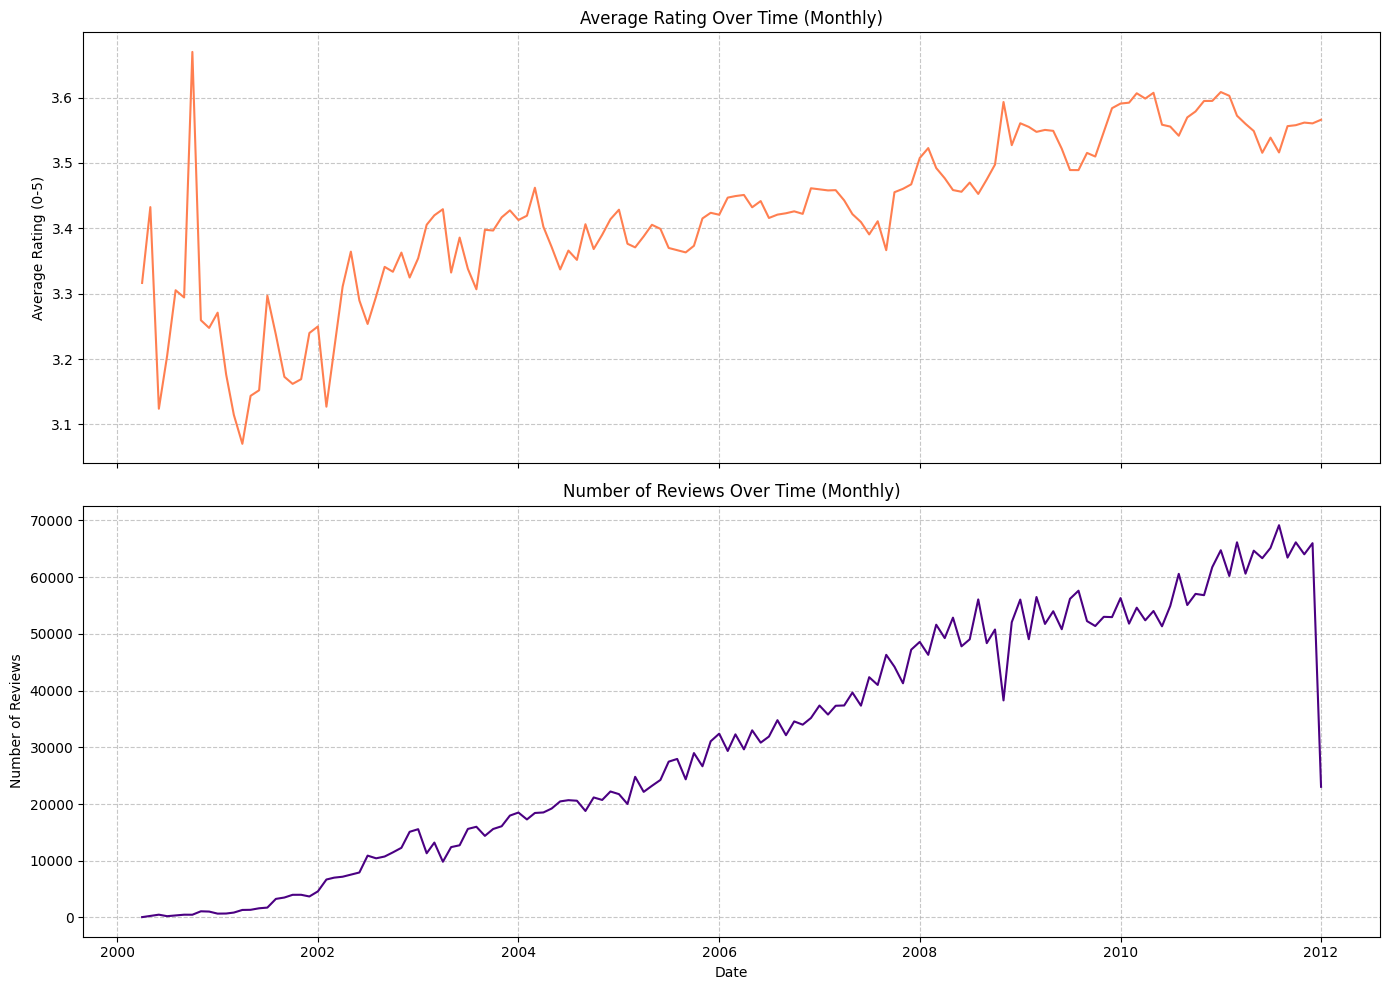

In [13]:
import pandas as pd

# Convert 'review/time' (UNIX timestamp) to datetime objects
df_unified['review_datetime'] = pd.to_datetime(pd.to_numeric(df_unified['review/time'], errors='coerce'), unit='s')

# Drop rows where datetime or rating is missing to ensure clean plots
df_time = df_unified.dropna(subset=['review_datetime', 'rating']).copy()

# Create a Year-Month column for aggregation
df_time['year_month'] = df_time['review_datetime'].dt.to_period('M').dt.to_timestamp()

# Calculate monthly average rating and review counts
monthly_stats = df_time.groupby('year_month').agg(
    avg_rating=('rating', 'mean'),
    review_count=('rating', 'size')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot Average Rating Over Time
sns.lineplot(data=monthly_stats, x='year_month', y='avg_rating', ax=axes[0], color='coral')
axes[0].set_title('Average Rating Over Time (Monthly)')
axes[0].set_ylabel('Average Rating (0-5)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot Review Count Over Time
sns.lineplot(data=monthly_stats, x='year_month', y='review_count', ax=axes[1], color='indigo')
axes[1].set_title('Number of Reviews Over Time (Monthly)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Reviews')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Bolstered Dataset for Advanced Models

In [14]:
# 1. Basic Dataset (User, Item, Rating triplets only)
df_basic = df_unified[['user_id', 'item_id', 'rating']].copy()
print("=== Basic Dataset ===")
print(f"Shape: {df_basic.shape}")
display(df_basic.head(3))

# 2. Advanced Dataset (All available features)
# Concatenate all data
df_advanced = pd.concat([df_rb_merge, df_ba_merge], ignore_index=True)

# Drop duplicates for the advanced dataset
print(f"\nAdvanced records before dropping duplicates: {len(df_advanced)}")
df_advanced.drop_duplicates(subset=['user_id', 'item_id'], keep='first', inplace=True)
print(f"Advanced records after dropping duplicates: {len(df_advanced)}")

# Drop the old unparsed ID/rating columns to avoid confusion and save memory
cols_to_drop = ['review/profileName', 'beer/beerId', 'review/overall', 'source']
df_advanced.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Convert sub-ratings to numeric 0-5 scale using the previously defined parse_fraction function
sub_rating_cols = ['review/appearance', 'review/aroma', 'review/palate', 'review/taste']

print("\nParsing sub-ratings into numeric formats...")
for col in sub_rating_cols:
    df_advanced[col] = df_advanced[col].apply(parse_fraction)

# Convert review/time to numeric (UNIX timestamp)
df_advanced['review/time'] = pd.to_numeric(df_advanced['review/time'], errors='coerce')

# Reorder columns to make user_id, item_id, and rating the first three columns
first_cols = ['user_id', 'item_id', 'rating']
other_cols = [col for col in df_advanced.columns if col not in first_cols]
df_advanced = df_advanced[first_cols + other_cols]

print("\n=== Advanced Dataset ===")
print(f"Shape: {df_advanced.shape}")
display(df_advanced.head(3))

print("\nAdvanced Dataset Columns:")
for col in df_advanced.columns:
    print(f"- {col}")

=== Basic Dataset ===
Shape: (4426824, 3)


,user_id,item_id,rating
0,rb_hopdog,rb_63836,3.25
1,rb_TomDecapolis,rb_63836,3.25
2,rb_PhillyBeer2112,rb_71716,3.50



Advanced records before dropping duplicates: 4510556
Advanced records after dropping duplicates: 4426824

Parsing sub-ratings into numeric formats...

=== Advanced Dataset ===
Shape: (4426824, 13)


,user_id,item_id,rating,beer/name,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/time,review/text
0,rb_hopdog,rb_63836,3.25,John Harvards Simcoe IPA,8481,5.4,India Pale Ale &#40;IPA&#41;,4.0,3.0,3.0,3.0,1157587200,"On tap at the Springfield, PA location. Poured..."
1,rb_TomDecapolis,rb_63836,3.25,John Harvards Simcoe IPA,8481,5.4,India Pale Ale &#40;IPA&#41;,4.0,3.0,4.0,3.5,1157241600,On tap at the John Harvards in Springfield PA....
2,rb_PhillyBeer2112,rb_71716,3.50,John Harvards Cristal Pilsner,8481,5,Bohemian Pilsener,4.0,2.5,3.0,3.0,958694400,"UPDATED: FEB 19, 2003 Springfield, PA. I've ne..."



Advanced Dataset Columns:
- user_id
- item_id
- rating
- beer/name
- beer/brewerId
- beer/ABV
- beer/style
- review/appearance
- review/aroma
- review/palate
- review/taste
- review/time
- review/text


### Temporal 80/20 Train/Test Data Split

In [15]:
import os

# Create a directory to store the processed datasets
os.makedirs('/content/processed_data', exist_ok=True)

print("Sorting data chronologically for temporal split...")
# Use df_advanced since it has the parsed review/time column
df_advanced_sorted = df_advanced.sort_values('review/time').dropna(subset=['review/time'])

split_idx = int(len(df_advanced_sorted) * 0.8)

print("Splitting chronologically (80% Train, 20% Test)...")
advanced_train = df_advanced_sorted.iloc[:split_idx].copy()
advanced_test = df_advanced_sorted.iloc[split_idx:].copy()

# Derive basic datasets from advanced splits to ensure consistency
basic_cols = ['user_id', 'item_id', 'rating']
basic_train = advanced_train[basic_cols].copy()
basic_test = advanced_test[basic_cols].copy()

print("\nSaving temporal splits to Parquet...")
basic_train.to_parquet('/content/processed_data/basic_train_temporal.parquet', index=False)
basic_test.to_parquet('/content/processed_data/basic_test_temporal.parquet', index=False)
advanced_train.to_parquet('/content/processed_data/advanced_train_temporal.parquet', index=False)
advanced_test.to_parquet('/content/processed_data/advanced_test_temporal.parquet', index=False)

print("\n=== Temporal Split Statistics ===")
print(f"Basic Train Shape: {basic_train.shape}")
print(f"Basic Test Shape: {basic_test.shape}")
print(f"Advanced Train Shape: {advanced_train.shape}")
print(f"Advanced Test Shape: {advanced_test.shape}")
print("\nDatasets successfully saved to '/content/processed_data/'!")

Sorting data chronologically for temporal split...
Splitting chronologically (80% Train, 20% Test)...

Saving temporal splits to Parquet...

=== Temporal Split Statistics ===
Basic Train Shape: (3541459, 3)
Basic Test Shape: (885365, 3)
Advanced Train Shape: (3541459, 13)
Advanced Test Shape: (885365, 13)

Datasets successfully saved to '/content/processed_data/'!


### Train/Test Temporal Analysis

=== Temporal Split Timeline ===
Train Start Date: 2000-04-05 00:00:01
Train End Date:   2010-11-16 06:33:21
Test Start Date:  2010-11-16 06:35:44
Test End Date:    2012-01-13 00:00:00


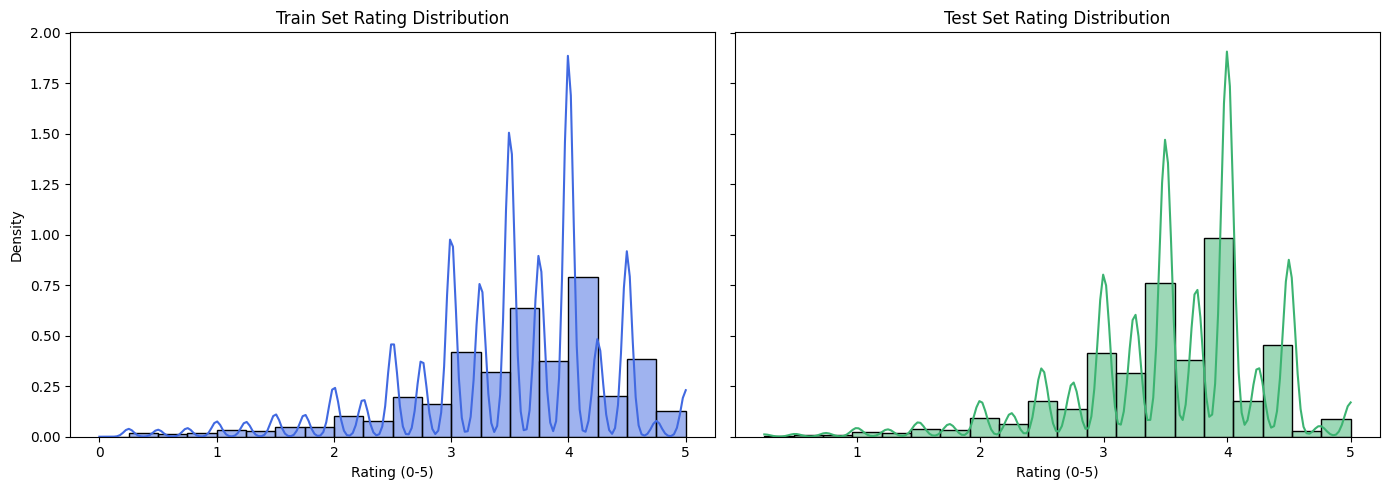

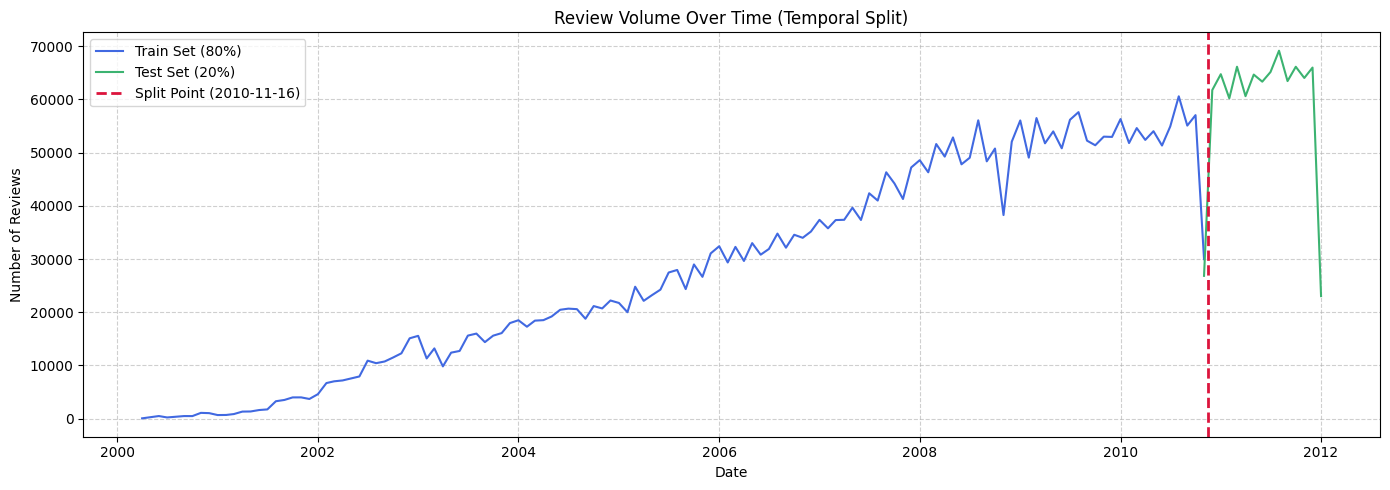

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert UNIX timestamps to readable datetime objects for analysis
train_dates = pd.to_datetime(advanced_train['review/time'], unit='s')
test_dates = pd.to_datetime(advanced_test['review/time'], unit='s')

print("=== Temporal Split Timeline ===")
print(f"Train Start Date: {train_dates.min()}")
print(f"Train End Date:   {train_dates.max()}")
print(f"Test Start Date:  {test_dates.min()}")
print(f"Test End Date:    {test_dates.max()}")

# 1. Plot Rating Distributions (Train vs Test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(advanced_train['rating'], bins=20, kde=True, ax=axes[0], color='royalblue', stat='density')
axes[0].set_title('Train Set Rating Distribution')
axes[0].set_xlabel('Rating (0-5)')
axes[0].set_ylabel('Density')

sns.histplot(advanced_test['rating'], bins=20, kde=True, ax=axes[1], color='mediumseagreen', stat='density')
axes[1].set_title('Test Set Rating Distribution')
axes[1].set_xlabel('Rating (0-5)')

plt.tight_layout()
plt.show()

# 2. Plot Review Volume Over Time
# Create a temporary column for monthly aggregation
advanced_train['review_month'] = train_dates.dt.to_period('M').dt.to_timestamp()
advanced_test['review_month'] = test_dates.dt.to_period('M').dt.to_timestamp()

train_monthly = advanced_train.groupby('review_month').size()
test_monthly = advanced_test.groupby('review_month').size()

plt.figure(figsize=(14, 5))
plt.plot(train_monthly.index, train_monthly.values, label='Train Set (80%)', color='royalblue')
plt.plot(test_monthly.index, test_monthly.values, label='Test Set (20%)', color='mediumseagreen')

# Draw a vertical line to indicate the split point
split_point = train_dates.max()
plt.axvline(x=split_point, color='crimson', linestyle='--', linewidth=2, label=f'Split Point ({split_point.date()})')

plt.title('Review Volume Over Time (Temporal Split)')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Clean up temporary columns
advanced_train.drop(columns=['review_month'], inplace=True, errors='ignore')
advanced_test.drop(columns=['review_month'], inplace=True, errors='ignore')